#**ANGGOT KELOMPOK :**
#**MUHAMMAD SYAHRAZZA (25031554119)**
#**HENGRY MICHAELI JOYO SUSETYO (25031554142)**
#**MUHAMMAD NAUFAL AKIF MAGAL (25031554183)**

#**HTTP (MICHAEL)**

In [96]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

# URL target
main_url = "https://www.bbc.com/news/war-in-ukraine"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

def get_author(article_url):
    """Fungsi untuk mengambil nama penulis langsung dari halaman artikel"""
    try:
        res = requests.get(article_url, headers=headers, timeout=5)
        res.raise_for_status()
        article_soup = BeautifulSoup(res.text, "html.parser")

        # 1. Cari via tag meta HTML (metode paling umum di situs berita)
        meta_author = article_soup.find("meta", {"name": "author"}) or article_soup.find("meta", {"property": "article:author"})
        if meta_author and meta_author.get("content"):
            return meta_author["content"]

        # 2. Cari via atribut data-testid khusus BBC
        byline = article_soup.find(attrs={"data-testid": "byline-name"})
        if byline:
            return byline.get_text(strip=True)

        return "BBC News (Penulis tidak tertera)"
    except Exception:
        return "Gagal mengambil data penulis"

try:
    print("Mengambil daftar berita dari BBC war-in-ukraine\n")
    response = requests.get(main_url, headers=headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    # Mencari tag <a> yang memiliki judul berita (h2/h3) di dalamnya
    articles = []
    seen_links = set()

    for a_tag in soup.find_all("a", href=True):
        headline_tag = a_tag.find(["h2", "h3"])
        if headline_tag:
            title = headline_tag.get_text(strip=True)
            # Mengubah relative URL (/news/...) menjadi absolute URL (https://www.bbc.com/news/...)
            full_link = urljoin("https://www.bbc.com", a_tag["href"])

            if title and full_link not in seen_links:
                seen_links.add(full_link)
                articles.append({"title": title, "link": full_link})

    # Membatasi pengambilan berita (misal: 5 berita pertama) agar proses tidak terlalu lama
    limit = 15
    print(f"=== Menampilkan {min(limit, len(articles))} Berita Terbaru ===\n")

    for i, art in enumerate(articles[:limit], 1):
        print(f"[{i}] Judul   : {art['title']}")
        print(f"    Sumber  : {art['link']}")

        # Ambil penulis dengan membuka halaman artikel
        author = get_author(art['link'])
        print(f"    Penulis : {author}")
        print("-" * 60)

except requests.exceptions.RequestException as e:
    print(f"Terjadi kesalahan saat mengambil data: {e}")

Mengambil daftar berita dari BBC war-in-ukraine

=== Menampilkan 12 Berita Terbaru ===

[1] Judul   : Ship sinks and crew missing after Black Sea drone attack
    Sumber  : https://www.bbc.com/news/articles/c8ly0v5r602eo
    Penulis : BBC News (Penulis tidak tertera)
------------------------------------------------------------
[2] Judul   : Fear and disruption for Ukraine's rail passengers as Russia escalates drone attacks
    Sumber  : https://www.bbc.com/news/articles/cr4g1qxzwyj1o
    Penulis : BBC News (Penulis tidak tertera)
------------------------------------------------------------
[3] Judul   : Former Scots schoolboy killed in battle honoured at Ukrainian chapel
    Sumber  : https://www.bbc.com/news/articles/c6rry5yj1ee4o
    Penulis : BBC News (Penulis tidak tertera)
------------------------------------------------------------
[4] Judul   : Zelensky condemns 'horrific' Russian strike on boat carrying corn in Black Sea
    Sumber  : https://www.bbc.com/news/articles/cr0j0w3p8

#**API (SYAHRAZZA)**

In [97]:
import requests
import pandas as pd

jumlah_data = 10
url = f"https://dummyjson.com/quotes?limit={jumlah_data}"
response = requests.get(url)
print("Status Code:", response.status_code)
data = response.json()
quotes = data["quotes"]
df_api = pd.DataFrame(quotes)
print("Total data:", len(df_api))
df_api

Status Code: 200
Total data: 10


,id,quote,author
0,1,Your heart is the size of an ocean. Go find yourself in its hidden depths.,Rumi
1,2,"The Bay of Bengal is hit frequently by cyclones. The months of November and May, in particular, are dangerous in this regard.",Abdul Kalam
2,3,"Thinking is the capital, Enterprise is the way, Hard Work is the solution.",Abdul Kalam
3,4,"If You Can'T Make It Good, At Least Make It Look Good.",Bill Gates
4,5,"Heart be brave. If you cannot be brave, just go. Love's glory is not a small thing.",Rumi
5,6,It is bad for a young man to sin; but it is worse for an old man to sin.,Abu Bakr (R.A)
6,7,"If You Are Out To Describe The Truth, Leave Elegance To The Tailor.",Albert Einstein
7,8,"O man you are busy working for the world, and the world is busy trying to turn you out.",Abu Bakr (R.A)
8,9,"While children are struggling to be unique, the world around them is trying all means to make them look like everybody else.",Abdul Kalam
9,10,"These Capitalists Generally Act Harmoniously And In Concert, To Fleece The People.",Abraham Lincoln


In [98]:
awal = 21
akhir = 40
jumlah_data = akhir - awal + 1
skip = awal - 1
url = f"https://dummyjson.com/quotes?limit={jumlah_data}&skip={skip}"
response = requests.get(url)
data = response.json()
df_api_range = pd.DataFrame(data["quotes"])
print(f"Menampilkan data {awal} sampai {akhir}")
print("Jumlah data:", len(df_api_range))
df_api_range

Menampilkan data 21 sampai 40
Jumlah data: 20


,id,quote,author
0,21,Respond to every call that excites your spirit.,Rumi
1,22,The Way To Get Started Is To Quit Talking And Begin Doing.,Walt Disney
2,23,"God Doesn'T Require Us To Succeed, He Only Requires That You Try.",Mother Teresa
3,24,"Speak any language, Turkish, Greek, Persian, Arabic, but always speak with love.",Rumi
4,25,Happiness comes towards those which believe in him.,Ali ibn Abi Talib (R.A)
5,26,Knowledge is of two kinds: that which is absorbed and that which is heard. And that which is heard does not profit if it is not absorbed.,Ali ibn Abi Talib (R.A)
6,27,"When I am silent, I have thunder hidden inside.",Rumi
7,28,Technological Progress Is Like An Axe In The Hands Of A Pathological Criminal.,Albert Einstein
8,29,No One Would Choose A Friendless Existence On Condition Of Having All The Other Things In The World.,Aristotle
9,30,"Life is a gamble. You can get hurt, but people die in plane crashes, lose their arms and legs in car accidents; people die every day. Same with fighters: some die, some get hurt, some go on. You just don't let yourself believe it will happen to you.",Muhammad Ali


#**Teks Pre-Processing (Naufal)**

In [99]:
!pip install demoji

In [100]:
import re
import string
import matplotlib.pyplot as plt
import itertools
import demoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud

In [101]:
df_api_range["quote"]

,quote
0,Respond to every call that excites your spirit.
1,The Way To Get Started Is To Quit Talking And Begin Doing.
2,"God Doesn'T Require Us To Succeed, He Only Requires That You Try."
3,"Speak any language, Turkish, Greek, Persian, Arabic, but always speak with love."
4,Happiness comes towards those which believe in him.
5,Knowledge is of two kinds: that which is absorbed and that which is heard. And that which is heard does not profit if it is not absorbed.
6,"When I am silent, I have thunder hidden inside."
7,Technological Progress Is Like An Axe In The Hands Of A Pathological Criminal.
8,No One Would Choose A Friendless Existence On Condition Of Having All The Other Things In The World.
9,"Life is a gamble. You can get hurt, but people die in plane crashes, lose their arms and legs in car accidents; people die every day. Same with fighters: some die, some get hurt, some go on. You just don't let yourself believe it will happen to you."


#**Buat WordCloud**

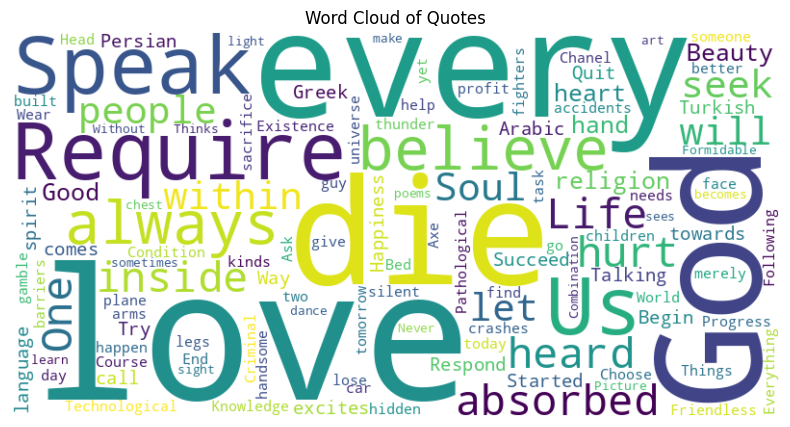

In [102]:
all_words = ' '.join([text for text in df_api_range["quote"] if isinstance(text, str)])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Quotes')
plt.show()

#**Menghilangkan Hastag `#` pada Quotes**



In [103]:
def remove_hashtag(text):
    return re.sub(r'#\w+', '', text)

result = df_api_range["quote"].apply(remove_hashtag)
print(result)

0                                                                                                                                                                                                               Respond to every call that excites your spirit.
1                                                                                                                                                                                                    The Way To Get Started Is To Quit Talking And Begin Doing.
2                                                                                                                                                                                             God Doesn'T Require Us To Succeed, He Only Requires That You Try.
3                                                                                                                                                                              Speak any language, Turkish, Greek, Persian, Arabic, but 

#**Mengubah seluruh huruf pada Quote menjadi huruf kecil**

In [104]:
result_lower = result.str.lower()
print(result_lower)

0                                                                                                                                                                                                               respond to every call that excites your spirit.
1                                                                                                                                                                                                    the way to get started is to quit talking and begin doing.
2                                                                                                                                                                                             god doesn't require us to succeed, he only requires that you try.
3                                                                                                                                                                              speak any language, turkish, greek, persian, arabic, but 

#**Menghapus Link pada Quotes jika ada**

In [105]:
def remove_rls(text):
    text = re.sub(r'https?\/\/S+', '',  str(text)) # remove the hyperlink
    text = re.sub(r'http\S+', '',  str(text)) # remove the hyperlink
    text = re.sub(r'www\S+', '',  str(text)) # remove the www
    text = re.sub(r'\S+@\S+', '', str(text)) # remove the email
    return text

result_lower_no_rls = result_lower.apply(remove_rls)
print(result_lower_no_rls)

0                                                                                                                                                                                                               respond to every call that excites your spirit.
1                                                                                                                                                                                                    the way to get started is to quit talking and begin doing.
2                                                                                                                                                                                             god doesn't require us to succeed, he only requires that you try.
3                                                                                                                                                                              speak any language, turkish, greek, persian, arabic, but 

#**Menghapus Punctuation pada Quote jika ada**

In [106]:
def remove_punctuation_list(text):
    # List Emoticon
    text = re.sub(r'(:\)|:-\)|:D|:-D|;\)|;-\))', '', text)
    text = re.sub(r'(:\(|:-\()', '', text)
    text = re.sub(r'(:v|:-v)', '', text)

    # remove punctuation
    text = re.sub(r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

result_lower_no_rls_no_punct = result_lower_no_rls.apply(remove_punctuation_list)
print(result_lower_no_rls_no_punct)

0                                                                                                                                                                                                      respond to every call that excites your spirit
1                                                                                                                                                                                           the way to get started is to quit talking and begin doing
2                                                                                                                                                                                     god doesn t require us to succeed he only requires that you try
3                                                                                                                                                                          speak any language turkish greek persian arabic but always speak with love
4               

#**Menghilangkan Emoji pada Quote jika ada**

In [107]:
def remove_emoji(text):
    cleaned_text = demoji.replace(text,repl="") # Replaces emojis with an empty string
    #cleaned_text = demoji.replace_with_desc(text) # Replaces emojis with text
    return cleaned_text

result_lower_no_rls_no_punct_no_emoji = result_lower_no_rls_no_punct.apply(remove_emoji)
print(result_lower_no_rls_no_punct_no_emoji)

0                                                                                                                                                                                                      respond to every call that excites your spirit
1                                                                                                                                                                                           the way to get started is to quit talking and begin doing
2                                                                                                                                                                                     god doesn t require us to succeed he only requires that you try
3                                                                                                                                                                          speak any language turkish greek persian arabic but always speak with love
4               

In [108]:
nltk.download('stopwords')

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#**Menghilangkan StopWords pada Quote jika ada**

In [109]:
sw = set(stopwords.words('english'))
def remove_stopwords(text):
  return " ".join([word for word in str(text).split() if word not in sw])

result_lower_no_rls_no_punct_no_emoji_no_stopwords = result_lower_no_rls_no_punct_no_emoji.apply(remove_stopwords)
print(result_lower_no_rls_no_punct_no_emoji_no_stopwords)

0                                                                                                               respond every call excites spirit
1                                                                                                              way get started quit talking begin
2                                                                                                             god require us succeed requires try
3                                                                                   speak language turkish greek persian arabic always speak love
4                                                                                                                 happiness comes towards believe
5                                                                                        knowledge two kinds absorbed heard heard profit absorbed
6                                                                                                                    silent 

#**Menghilangkan 3 kata yang paling sering muncul pada Quote**

In [110]:
# Combine all text into a single string
all_words_processed = ' '.join(result_lower_no_rls_no_punct_no_emoji_no_stopwords)

# Tokenize and count word frequencies
words = all_words_processed.split()
word_counts = Counter(words)

# Get the top 3 most frequent words
top_3_words = [word for word, count in word_counts.most_common(3)]
print(f"Top 3 most frequent words: {top_3_words}")

# Function to remove the top 3 words
def remove_top_words(text, words_to_remove):
    return " ".join([word for word in text.split() if word not in words_to_remove])

# Apply the function to the variable
result_without_top_3_words = result_lower_no_rls_no_punct_no_emoji_no_stopwords.apply(lambda x: remove_top_words(x, top_3_words))

print("\nText after removing top 3 words:")
print(result_without_top_3_words)

Top 3 most frequent words: ['love', 'every', 'get']

Text after removing top 3 words:
0                                                                                                       respond call excites spirit
1                                                                                                    way started quit talking begin
2                                                                                               god require us succeed requires try
3                                                                          speak language turkish greek persian arabic always speak
4                                                                                                   happiness comes towards believe
5                                                                          knowledge two kinds absorbed heard heard profit absorbed
6                                                                                                      silent thunder hidd

#**Menghilangkan 3 kata yang paling jarang muncul pada Quote**

In [111]:
# Re-combine all text into a single string (if not already done or to ensure fresh count)
# Assuming 'result_lower_no_rls_no_punct_no_emoji_no_stopwords' is a pandas Series
all_words_processed_for_least = ' '.join(result_lower_no_rls_no_punct_no_emoji_no_stopwords.astype(str))

# Tokenize and count word frequencies
words_for_least = all_words_processed_for_least.split()
word_counts_for_least = Counter(words_for_least)

# Get the top 3 least frequent words (most_common() with slicing from the end)
# Note: If there are many words with frequency 1, this will pick any 3 of them.
top_3_least_words = [word for word, count in word_counts_for_least.most_common()[:-4:-1]]
print(f"Top 3 least frequent words: {top_3_least_words}")

# Function to remove specified words
def remove_least_words(text, words_to_remove):
    return " ".join([word for word in text.split() if word not in words_to_remove])

# Apply the function to the variable
result_without_least_3_words = result_lower_no_rls_no_punct_no_emoji_no_stopwords.apply(lambda x: remove_least_words(x, top_3_least_words))

print("\nText after removing top 3 least frequent words:")
print(result_without_least_3_words)


Top 3 least frequent words: ['art', 'becomes', 'sight']

Text after removing top 3 least frequent words:
0                                                                                                               respond every call excites spirit
1                                                                                                              way get started quit talking begin
2                                                                                                             god require us succeed requires try
3                                                                                   speak language turkish greek persian arabic always speak love
4                                                                                                                 happiness comes towards believe
5                                                                                        knowledge two kinds absorbed heard heard profit absorbed
6                  

#**Melakukan Stemming pada Quote dengan SnowballStemmer**

In [112]:
ss = SnowballStemmer("english")
def stemming(text):
    return " ".join([ss.stem(word) for word in text.split()])

result_stemmed = result_without_least_3_words.apply(stemming)
print("\nText after stemming:")
print(result_stemmed)


Text after stemming:
0                                                                                                    respond everi call excit spirit
1                                                                                                      way get start quit talk begin
2                                                                                                   god requir us succeed requir tri
3                                                                          speak languag turkish greek persian arab alway speak love
4                                                                                                           happi come toward believ
5                                                                                 knowledg two kind absorb heard heard profit absorb
6                                                                                                        silent thunder hidden insid
7                                              

#**Melakukan Lemmatization pada Quote dengan WordNetLemmatizer**

In [113]:
nltk.download('wordnet')
wnl = WordNetLemmatizer()

# Fungsi lemmatization sederhana menggunakan WordNetLemmatizer
def lemmatize_text(text):
    # Melakukan lemmatisasi untuk setiap kata. Secara default lemmatize mengasumsikan word class adalah Noun ('n').
    # Kita bisa meningkatkan dengan melabeli POS, namun untuk contoh ini kita gunakan default noun lemmatization
    # atau menyederhanakan kata dengan menyisir kata benda/kata kerja mendasar.
    return " ".join([wnl.lemmatize(word, pos='v') for word in text.split()])

# Menerapkan lemmatization ke variabel data teks bersih
result_lemmatized = result_without_least_3_words.apply(lemmatize_text)

print("\nText after Lemmatization:")
print(result_lemmatized)


Text after Lemmatization:
0                                                                                                             respond every call excite spirit
1                                                                                                                way get start quit talk begin
2                                                                                                           god require us succeed require try
3                                                                                speak language turkish greek persian arabic always speak love
4                                                                                                               happiness come towards believe
5                                                                                           knowledge two kinds absorb hear hear profit absorb
6                                                                                                                  

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#**Melakukan Tokenize/Tokenisasi pada Quote**

In [114]:
# Download the required resources for tokenization
nltk.download('punkt_tab')

# Function to perform tokenization
def tokenize_text(text):
    return nltk.word_tokenize(text)

# Apply tokenization to the pre-processed text variable
result_tokenized = result_without_least_3_words.apply(tokenize_text)

print("\nText after Tokenization:")
print(result_tokenized)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...



Text after Tokenization:
0                                                                                                                                   [respond, every, call, excites, spirit]
1                                                                                                                                 [way, get, started, quit, talking, begin]
2                                                                                                                                [god, require, us, succeed, requires, try]
3                                                                                                   [speak, language, turkish, greek, persian, arabic, always, speak, love]
4                                                                                                                                      [happiness, comes, towards, believe]
5                                                                                                         [knowled

[nltk_data]   Package punkt_tab is already up-to-date!


#**Melakukan Tagging pada Quote**

In [115]:
# Download resources yang dibutuhkan untuk POS tagging (termasuk tagger standar)
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Fungsi untuk melakukan POS Tagging menggunakan universal tagset
def pos_tag_text(tokens):
    return nltk.pos_tag(tokens, tagset='universal_tagset')

# Terapkan POS tagging pada variabel result_tokenized yang sudah dibuat sebelumnya
result_tagged = result_tokenized.apply(pos_tag_text)

print("Hasil POS Tagging:")
print(result_tagged)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Hasil POS Tagging:
0                                                                                                                                                                                                                                                                               [(respond, UNK), (every, UNK), (call, UNK), (excites, UNK), (spirit, UNK)]
1                                                                                                                                                                                                                                                                      [(way, UNK), (get, UNK), (started, UNK), (quit, UNK), (talking, UNK), (begin, UNK)]
2                                                                                                                                                                                                                                                                     [(god, UNK), (require, UN

#**Melakukan Chunking pada Quote dan menambahkannya sebagai kolom baru pada dataframe**

In [116]:
import nltk
import pandas as pd

# Definisikan aturan gramatikal untuk Noun Phrase (NP) Chunking
grammar = "NP: {<DET>?<ADJ>*<NOUN>+}"

# Membuat chunk parser menggunakan NLTK RegexpParser
chunk_parser = nltk.RegexpParser(grammar)

# Fungsi untuk menerapkan chunking pada setiap baris data
def perform_chunking(tagged_sentence):
    return chunk_parser.parse(tagged_sentence)

# Mengaplikasikan fungsi chunking pada data yang sudah di-tag
result_chunked = result_tagged.apply(perform_chunking)

# Mengubah struktur Tree dari hasil chunking menjadi format string agar mudah dibaca di DataFrame
chunked_strings = result_chunked.apply(lambda tree: str(tree).replace('\n', ' '))

# Membuat DataFrame untuk menyandingkan quote asli dan hasil chunking
df_chunking = pd.DataFrame({
    'Quote Asli': df_api_range["quote"],
    'Hasil Chunking (Tree String)': chunked_strings
})

# Menampilkan DataFrame hasil chunking
import pandas as pd
pd.set_option('display.max_colwidth', None)
df_chunking

,Quote Asli,Hasil Chunking (Tree String)
0,Respond to every call that excites your spirit.,(S respond/UNK every/UNK call/UNK excites/UNK spirit/UNK)
1,The Way To Get Started Is To Quit Talking And Begin Doing.,(S way/UNK get/UNK started/UNK quit/UNK talking/UNK begin/UNK)
2,"God Doesn'T Require Us To Succeed, He Only Requires That You Try.",(S god/UNK require/UNK us/UNK succeed/UNK requires/UNK try/UNK)
3,"Speak any language, Turkish, Greek, Persian, Arabic, but always speak with love.",(S speak/UNK language/UNK turkish/UNK greek/UNK persian/UNK arabic/UNK always/UNK speak/UNK love/UNK)
4,Happiness comes towards those which believe in him.,(S happiness/UNK comes/UNK towards/UNK believe/UNK)
5,Knowledge is of two kinds: that which is absorbed and that which is heard. And that which is heard does not profit if it is not absorbed.,(S knowledge/UNK two/UNK kinds/UNK absorbed/UNK heard/UNK heard/UNK profit/UNK absorbed/UNK)
6,"When I am silent, I have thunder hidden inside.",(S silent/UNK thunder/UNK hidden/UNK inside/UNK)
7,Technological Progress Is Like An Axe In The Hands Of A Pathological Criminal.,(S technological/UNK progress/UNK like/UNK axe/UNK hands/UNK pathological/UNK criminal/UNK)
8,No One Would Choose A Friendless Existence On Condition Of Having All The Other Things In The World.,(S one/UNK would/UNK choose/UNK friendless/UNK existence/UNK condition/UNK things/UNK world/UNK)
9,"Life is a gamble. You can get hurt, but people die in plane crashes, lose their arms and legs in car accidents; people die every day. Same with fighters: some die, some get hurt, some go on. You just don't let yourself believe it will happen to you.",(S life/UNK gamble/UNK get/UNK hurt/UNK people/UNK die/UNK plane/UNK crashes/UNK lose/UNK arms/UNK legs/UNK car/UNK accidents/UNK people/UNK die/UNK every/UNK day/UNK fighters/UNK die/UNK get/UNK hurt/UNK go/UNK let/UNK believe/UNK happen/UNK)


In [117]:
df_chunking[["Quote Asli"]].to_excel("DataFrame Quote.xlsx", index=False)

#**Melakukan One-Hot Encoding**

In [118]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. One-Hot Encoding pada Teks Quotes
# Menggunakan CountVectorizer dengan binary=True untuk menghasilkan matriks One-Hot Encoding per kata
vectorizer = CountVectorizer(binary=True)
one_hot_matrix = vectorizer.fit_transform(df_api_range["quote"])

# Mengubah matriks sparse menjadi DataFrame agar terlihat rapi
df_one_hot_quote = pd.DataFrame(
    one_hot_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(f"Hasil One-Hot Encoding Teks Quotes (Ukuran matriks: {df_one_hot_quote.shape}):")
display(df_one_hot_quote)



Hasil One-Hot Encoding Teks Quotes (Ukuran matriks: (20, 181)):


,absorbed,accidents,against,all,always,am,an,and,any,arabic,...,will,with,within,without,world,would,yet,you,your,yourself
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,1,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
9,0,1,0,0,0,0,0,1,0,0,...,1,1,0,0,0,0,0,1,0,1


#**Menghitung TF-IDF**

In [119]:
result_tokenized = result_without_least_3_words.apply(tokenize_text)
result_tokenized.head()

,quote
0,"[respond, every, call, excites, spirit]"
1,"[way, get, started, quit, talking, begin]"
2,"[god, require, us, succeed, requires, try]"
3,"[speak, language, turkish, greek, persian, arabic, always, speak, love]"
4,"[happiness, comes, towards, believe]"


In [120]:
for i in range(5):
    print("Sebelum :", result_without_least_3_words.iloc[i])
    print("Sesudah :", result_tokenized.iloc[i])
    print()

Sebelum : respond every call excites spirit
Sesudah : ['respond', 'every', 'call', 'excites', 'spirit']

Sebelum : way get started quit talking begin
Sesudah : ['way', 'get', 'started', 'quit', 'talking', 'begin']

Sebelum : god require us succeed requires try
Sesudah : ['god', 'require', 'us', 'succeed', 'requires', 'try']

Sebelum : speak language turkish greek persian arabic always speak love
Sesudah : ['speak', 'language', 'turkish', 'greek', 'persian', 'arabic', 'always', 'speak', 'love']

Sebelum : happiness comes towards believe
Sesudah : ['happiness', 'comes', 'towards', 'believe']



In [121]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(
    result_without_least_3_words
)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_df.head()

,absorbed,accidents,always,arabic,arms,ask,axe,barriers,beauty,bed,...,two,universe,us,way,wear,within,without,world,would,yet
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.416209,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.373278,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.273883,0.311579,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


#**Melakukan Word2Vec, FastText, serta Visualisasi**

In [122]:
!pip install gensim

In [123]:
import pandas as pd
import re
from gensim.models import Word2Vec

# Load dataset
df_quote = df_chunking[["Quote Asli"]]

# Preprocessing & Tokenisasi Teks
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

df_quote['tokens'] = df_quote['Quote Asli'].apply(preprocess)
sentences = df_quote['tokens'].tolist()

# Latih Model Word2Vec
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,  # Dimensi vektor embedding
    window=5,         # Jarak jangkauan konteks kata
    min_count=1,      # Batas kemunculan kata minimal
    workers=4,        # Thread pemrosesan
    sg=0              # 0 = CBOW, 1 = Skip-gram
)

# Simpan Model Word2Vec
w2v_model.save("word2vec_quote.w2v")

# Pengujian Model
print("Vektor kata 'love':\n", w2v_model.wv['love'])
print("\nKata yang paling mirip dengan 'love':")
print(w2v_model.wv.most_similar('love', topn=3))

Vektor kata 'love':
 [ 9.7044511e-03  8.1956079e-03  1.3112644e-03  5.1515019e-03
  1.3881339e-03 -6.5962779e-03 -1.3729667e-03  6.5741772e-03
 -4.7118603e-03 -4.0381993e-03  4.9589695e-03  2.6395004e-03
 -1.8725552e-03 -2.8332225e-03  6.0169720e-03 -5.6975954e-03
 -3.2384708e-03 -6.5474599e-03 -4.2867889e-03 -8.7010749e-03
 -4.4645993e-03 -8.4522814e-03  1.4247134e-03 -8.6551765e-03
 -9.9092918e-03 -8.1448331e-03 -6.8277544e-03  6.6687665e-03
  3.7421107e-03  3.5045619e-04 -2.8977406e-03 -7.3626735e-03
  5.6891324e-04  4.7109643e-04  1.3259525e-04  9.5259218e-04
  8.4576156e-04 -7.1394054e-05 -8.0261715e-03 -5.9447926e-03
 -8.3865914e-03 -1.4169812e-03  1.7918248e-03  7.3632072e-03
 -1.9395542e-03 -2.3156237e-03  9.4798459e-03  5.4592965e-05
 -2.3521476e-03  8.6202379e-03  2.7192410e-03 -5.4160631e-03
  6.5701832e-03  4.4941436e-03 -6.9902800e-03 -3.0275714e-04
  8.2951563e-04  5.7658423e-03 -1.7448085e-03 -2.6966969e-03
  1.6986458e-03  8.5045479e-04  1.2448588e-03 -2.6616135e-03
 -6

In [124]:
from gensim.models import FastText

# Latih Model FastText
ft_model = FastText(
    sentences=sentences,
    vector_size=100,  # Dimensi vektor embedding
    window=5,         # Jarak jangkauan konteks kata
    min_count=1,      # Batas kemunculan kata minimal
    workers=4,        # Thread pemrosesan
    sg=0              # 0 = CBOW, 1 = Skip-gram
)

# Simpan Model FastText
ft_model.save("fasttext_quote.model")

# Pengujian Model (FastText mampu menangani Out-of-Vocabulary / OOV kata baru)
print("Vektor kata 'love':\n", ft_model.wv['love'])
print("\nKata yang mirip dengan 'loving' (meskipun kata 'loving' tidak ada di dataset):")
print(ft_model.wv.most_similar('loving', topn=3))

Vektor kata 'love':
 [-3.2219656e-03  8.4171019e-04 -1.4348560e-03  3.1976618e-03
  2.2141454e-03 -5.5090454e-04 -7.7305263e-04  5.0522608e-04
 -1.8684742e-03  4.1202328e-04  4.6569898e-05  2.8373820e-03
  4.9542455e-04  1.7938215e-03  1.3497943e-03  1.9179329e-03
 -7.0446660e-04  3.2563822e-03  3.8485881e-04 -2.9532216e-03
 -5.7047914e-04 -1.4971726e-03  2.8290586e-03  3.6345933e-05
 -7.1397645e-04 -6.6927954e-04 -1.4935900e-03  4.1885898e-03
  4.5039672e-03  4.6107851e-04  1.7656069e-03 -2.6812218e-04
  5.4919341e-04  1.8518608e-03 -1.2471269e-04  2.7802234e-04
 -8.3827111e-04  2.0548587e-03 -1.3325663e-03  2.1776389e-03
 -3.3665763e-04 -2.3218754e-03  8.7359990e-04  1.4434174e-03
 -6.6963176e-04  2.3166479e-03  1.5846868e-03 -8.4267673e-04
 -4.6388377e-04 -1.0929480e-03 -7.6918048e-04  3.1112372e-03
  1.3328939e-03  2.5773645e-04 -3.6805444e-03 -1.1462800e-03
 -6.4306794e-04 -1.6000652e-04  2.7269665e-03  6.7700364e-04
  9.5962436e-04  2.2857522e-03  9.6429850e-04 -2.9133433e-03
 -1

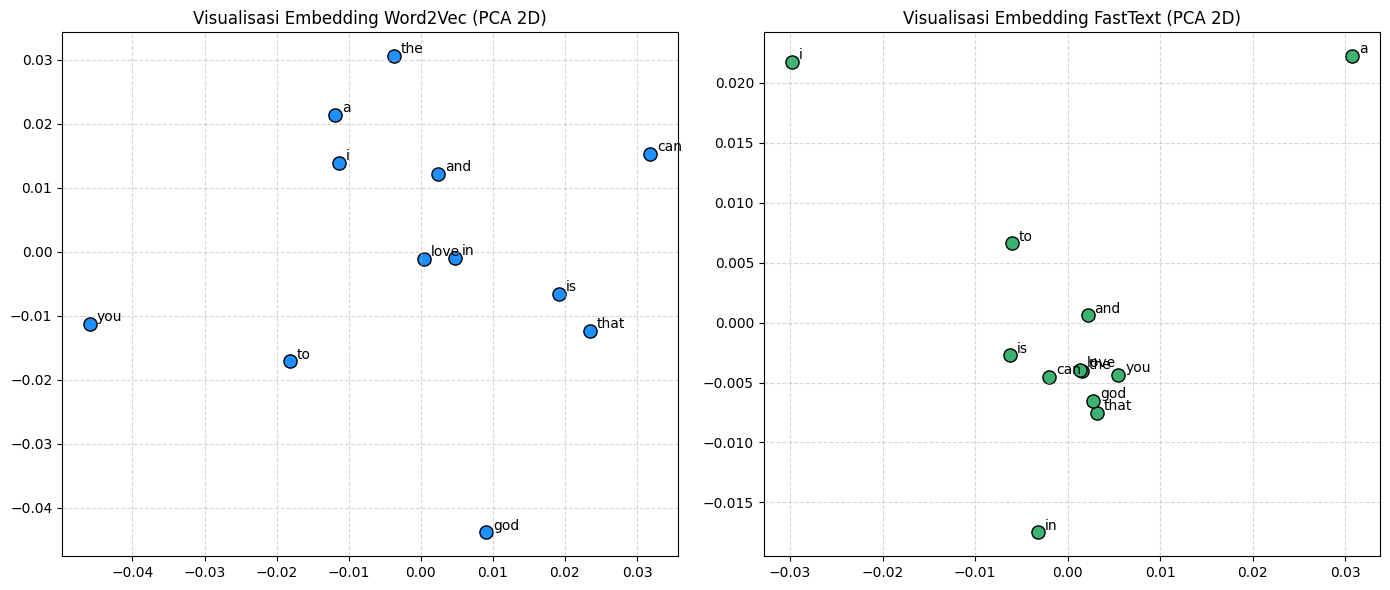

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec, FastText
from sklearn.decomposition import PCA

# Load Model yang Sudah Dilatih
w2v_model = Word2Vec.load("word2vec_quote.w2v")
ft_model = FastText.load("fasttext_quote.model")

# Daftar kata yang ingin divisualisasikan
words = ['is', 'in', 'to', 'the', 'a', 'you', 'that', 'and', 'i', 'love', 'god', 'can']

# Ambil vektor kata dari masing-masing model
w2v_vectors = [w2v_model.wv[w] for w in words]
ft_vectors = [ft_model.wv[w] for w in words]

# Reduksi Dimensi Vektor (100D -> 2D) Menggunakan PCA
pca = PCA(n_components=2, random_state=42)
w2v_2d = pca.fit_transform(w2v_vectors)
ft_2d = pca.fit_transform(ft_vectors)

# Plot Visualisasi Word2Vec vs FastText
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Word2Vec
axes[0].scatter(w2v_2d[:, 0], w2v_2d[:, 1], color='dodgerblue', s=90, edgecolors='k')
for i, word in enumerate(words):
    axes[0].annotate(word, (w2v_2d[i, 0], w2v_2d[i, 1]), xytext=(5, 2), textcoords='offset points', fontsize=10)
axes[0].set_title("Visualisasi Embedding Word2Vec (PCA 2D)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: FastText
axes[1].scatter(ft_2d[:, 0], ft_2d[:, 1], color='mediumseagreen', s=90, edgecolors='k')
for i, word in enumerate(words):
    axes[1].annotate(word, (ft_2d[i, 0], ft_2d[i, 1]), xytext=(5, 2), textcoords='offset points', fontsize=10)
axes[1].set_title("Visualisasi Embedding FastText (PCA 2D)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()